
# Caso E — OSIPTEL: Reclamos de usuarios en telecomunicaciones
### Fase 1 — Definición del problema, enriquecimiento y EDA

**Grupo 5**

---

## 1. Problema de negocio

OSIPTEL recibe un volumen muy alto de reclamos de usuarios de servicios de
telecomunicaciones, pero la información se publica de forma agregada y descriptiva:
se sabe *cuántos* reclamos hay, no *qué tan riesgosa* es realmente cada operadora
ni dónde conviene concentrar la fiscalización.

El área de supervisión necesita priorizar con criterio: no todas las empresas con
muchos reclamos son igual de problemáticas (una operadora grande naturalmente
recibe más reclamos que una pequeña), y no todos los reclamos escalan a una
infracción formal. Hoy esa priorización se hace de manera reactiva.

**Problema:** no existe un criterio cuantitativo que combine volumen de reclamos,
concentración por servicio/materia y exposición sancionadora real para priorizar
la supervisión de operadoras.

## 2. Pregunta huérfana

> *¿Las operadoras que acumulan más reclamos ante OSIPTEL son las mismas que
> efectivamente terminan sancionadas por INDECOPI, o el volumen de reclamos es un
> mal predictor del riesgo regulatorio real?*

Es huérfana porque **ningún dataset la responde por sí solo**: OSIPTEL tiene los
reclamos pero no las sanciones; INDECOPI tiene las sanciones pero no los reclamos.
Solo el cruce de ambas fuentes permite contestarla.

## 3. Preguntas analíticas

1. ¿Qué operadoras concentran el mayor volumen de reclamos presentados (2023–2025)?
2. ¿Qué servicios y materias reclamables concentran el problema?
3. ¿Cómo se distribuyen geográficamente los reclamos por departamento?
4. ¿Cuál es la evolución mensual del volumen de reclamos por operadora?
5. ¿Existe correlación entre el volumen de reclamos (OSIPTEL) y las sanciones y
   montos en UIT impuestos (INDECOPI)?
6. ¿Qué proporción de las operadoras con reclamos llega a tener sanción formal?

## 4. Datasets

| # | Fuente | Contenido | Rol |
|---|--------|-----------|-----|
| 1 | OSIPTEL — Reclamos presentados | Reclamos por empresa, mes, servicio, materia, departamento | **Base** |
| 2 | INDECOPI — Sanciones a proveedores | Total de sanciones y monto en UIT por razón social | **Enriquecimiento** |
| 3 | Encuestas - Dataset | Experiencia y Fricción de Usuario | **Eniquecimiento**


## 5. Estrategia de enriquecimiento

El dataset base de OSIPTEL se enriquece con la fuente pública de INDECOPI mediante
un **cruce por razón social normalizada**. Como los nombres no coinciden
literalmente entre ambas fuentes (tildes, puntuación, sufijos societarios,
mayúsculas), se aplica una función de normalización antes del `merge`.

El resultado es un dataset consolidado que incorpora dos variables nuevas a nivel
de operadora: `total_sanciones` y `monto_uit`.



In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
# ============================================================
# Configuración del entorno
# ============================================================
import os
import re
import logging
import warnings
import unicodedata

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

mpl.rcParams.update(mpl.rcParamsDefault)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

# Sufijos societarios a eliminar al normalizar razones sociales
SUFIJOS = (r"\b(SAA|SAC|SA|SRL|SCRL|EIRL|SOCIEDAD ANONIMA( ABIERTA| CERRADA)?|"
           r"SUCURSAL|DEL PERU|PERU|PERUANA|LTDA|LTD|INC|CORP|COMPANY|GROUP)\b")

def normalizar_empresa(nombre):
    """Normaliza un nombre de empresa para poder cruzar fuentes distintas
    (razón social completa de OSIPTEL vs nombre corto que la gente escribe
    en una encuesta)."""
    if pd.isna(nombre):
        return np.nan
    txt = str(nombre).upper().strip()
    txt = ''.join(c for c in unicodedata.normalize('NFKD', txt)
                  if not unicodedata.combining(c))
    txt = txt.replace('.', '')
    txt = re.sub(r'[^\w\s]', ' ', txt)
    for _ in range(3):
        txt = re.sub(SUFIJOS, ' ', txt)
        txt = re.sub(r'\s+', ' ', txt).strip()
    return txt if txt else np.nan

print("pandas:", pd.__version__, "| seaborn:", sns.__version__)

pandas: 2.2.3 | seaborn: 0.13.2


In [32]:
# ============================================================
# RUTAS  <-- AJUSTA ESTO a tu carpeta real
# ============================================================
BASE_DIR = '/content/drive/MyDrive/AD3010_CasoE'
PROC_DIR = f'{BASE_DIR}/data/processed'
os.makedirs(PROC_DIR, exist_ok=True)

# AJUSTA los nombres de archivo exactos (cópialos de tu Drive, con mayúsculas y todo)
path_osiptel  = f'{BASE_DIR}/10.1 RECLAMOS PRESENTADOS.xlsx'
path_encuesta = f'{BASE_DIR}/Encuestas.xlsx'

for p in [path_osiptel, path_encuesta]:
    print(("OK   " if os.path.exists(p) else "FALTA"), p)

OK    /content/drive/MyDrive/AD3010_CasoE/10.1 RECLAMOS PRESENTADOS.xlsx
OK    /content/drive/MyDrive/AD3010_CasoE/Encuestas.xlsx


In [33]:
# ============================================================
# Carga de datos
# ============================================================
df_presentados = pd.read_excel(path_osiptel, header=3)
encuesta        = pd.read_excel(path_encuesta)

print("OSIPTEL crudo :", df_presentados.shape)
print("Encuesta cruda:", encuesta.shape)

print("\nColumnas OSIPTEL:")
print(list(df_presentados.columns))
print("\nColumnas de la encuesta (cópialas si necesitas ajustar nombres más abajo):")
for c in encuesta.columns:
    print("  -", repr(c))

OSIPTEL crudo : (233892, 8)
Encuesta cruda: (59, 11)

Columnas OSIPTEL:
['Unnamed: 0', 'Empresa operadora', 'Mes', 'Departamento', 'Servicio involucrado', 'Forma de Presentación', 'Materia reclamable', 'N° de Reclamos Presentados']

Columnas de la encuesta (cópialas si necesitas ajustar nombres más abajo):
  - 'Marca temporal'
  - 'Puntuación'
  - '1. ¿Con qué empresa operadora tienes tu servicio principal?'
  - '2. ¿Qué tipo de servicio usas principalmente?'
  - '3. ¿En qué departamento resides?'
  - '5. ¿Has presentado un reclamo formal ante tu operador en los últimos 12 meses?'
  - '6. Si respondiste sí, ¿cuál fue el motivo principal de tu reclamo más reciente?'
  - '7. ¿Cuántas veces te comunicaste con atención al cliente en los últimos 3 meses por el mismo motivo?'
  - 'Si presentaste un reclamo, ¿qué tan fácil fue resolverlo con la empresa?'
  - '¿Qué tan probable es que cambies de operador en los próximos 6 meses?'
  - '¿Aceptas participar? 🙋🏻\u200d♀️'


# 8. EDA - Calidad de los datos (OSIPTEL, ya filtrado 2023-2025)

In [34]:
# ============================================================
# EDA 1: Calidad de datos - OSIPTEL
# ============================================================
print("Dimensiones:", df_presentados.shape)

resumen_nulos = pd.DataFrame({
    'nulos': df_presentados.isnull().sum(),
    'pct'  : (df_presentados.isnull().mean() * 100).round(2)
}).sort_values('nulos', ascending=False)
print("\nValores nulos (conteo y %):")
display(resumen_nulos)

print("\nRegistros duplicados:", df_presentados.duplicated().sum())

print("\nEstadísticas descriptivas:")
display(df_presentados[['N° de Reclamos Presentados']].describe())

print("\nRango temporal:", df_presentados['Mes'].min(), "->", df_presentados['Mes'].max())

Dimensiones: (233892, 8)

Valores nulos (conteo y %):


,nulos,pct
Unnamed: 0,233892,100.0
Empresa operadora,0,0.0
Mes,0,0.0
Departamento,0,0.0
Servicio involucrado,0,0.0
Forma de Presentación,0,0.0
Materia reclamable,0,0.0
N° de Reclamos Presentados,0,0.0



Registros duplicados: 10385

Estadísticas descriptivas:


,N° de Reclamos Presentados
count,233892.000000
mean,84.557706
std,1108.273532
min,1.000000
25%,1.000000
50%,2.000000
75%,8.000000
max,71299.000000



Rango temporal: 2016-01-01 00:00:00 -> 2025-12-31 00:00:00


In [35]:
import pandas as pd

# Carga el archivo de INDECOPI desde tu Drive/directorio
df_indecopi = pd.read_excel('ranking_proveedor.xlsx')

/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


# 6. Limpieza y preparación
Toda la limpieza se concentra en esta sección (en la versión anterior estaba dispersa y repetida en varias celdas).

Pasos:

1. Renombrar columnas de INDECOPI a nombres manejables.
2. Convertir guiones - y celdas vacías en NaN.
3. Eliminar columnas auxiliares y registros sin empresa.
4. Convertir MES a fecha y las columnas de sanciones a numérico.
5. Detectar y reportar duplicados.

In [36]:
# ============================================================
# Filtro temporal oficial del caso: 2023 - 2025
# ============================================================
df_presentados['Mes'] = pd.to_datetime(df_presentados['Mes'], errors='coerce')

FECHA_INICIO, FECHA_FIN = '2023-01-01', '2025-12-31'
antes = len(df_presentados)
df_presentados = df_presentados[
    (df_presentados['Mes'] >= FECHA_INICIO) & (df_presentados['Mes'] <= FECHA_FIN)
].copy()

print(f"Registros fuera de 2023-2025 eliminados: {antes - len(df_presentados)}")
print(f"Registros dentro del rango: {len(df_presentados)}")
print("Rango temporal:", df_presentados['Mes'].min(), "->", df_presentados['Mes'].max())

Registros fuera de 2023-2025 eliminados: 17476
Registros dentro del rango: 216416
Rango temporal: 2023-01-01 00:00:00 -> 2025-12-31 00:00:00


In [37]:
# ============================================================
# Limpieza 2: nulos, guiones y columnas auxiliares
# ============================================================
for df in [df_presentados, df_indecopi]:
    df.replace(r'^\s*-+\s*$', np.nan, regex=True, inplace=True)
    df.replace(r'^\s*$',      np.nan, regex=True, inplace=True)

# Quitar columnas auxiliares tipo "Unnamed"
cols_unnamed = [c for c in df_presentados.columns if str(c).startswith('Unnamed')]
if cols_unnamed:
    df_presentados = df_presentados.drop(columns=cols_unnamed)
    print("Columnas auxiliares eliminadas:", cols_unnamed)

# Registros sin empresa no aportan al análisis
antes = len(df_presentados)
df_presentados = df_presentados.dropna(subset=['Empresa operadora'])
print(f"Registros sin empresa eliminados: {antes - len(df_presentados)}")

Columnas auxiliares eliminadas: ['Unnamed: 0']
Registros sin empresa eliminados: 0


In [38]:
# 1. Asignar los nombres correctos a las columnas de INDECOPI
df_indecopi.columns = [
    'posicion',
    'razon_social',
    'nombre_comercial',
    'total_sanciones',
    'monto_uit',
]

# 2. Descartar las filas superiores que contenían los títulos institucionales del Excel
df_indecopi = df_indecopi.iloc[3:].reset_index(drop=True)

In [39]:
# ============================================================
# Limpieza 3: tipos de dato
# ============================================================
# Fecha
df_presentados['Mes'] = pd.to_datetime(df_presentados['Mes'], errors='coerce')

# Numéricos OSIPTEL
df_presentados['N° de Reclamos Presentados'] = pd.to_numeric(
    df_presentados['N° de Reclamos Presentados'], errors='coerce'
)

# Numéricos INDECOPI: vienen como texto con separadores de miles
def a_numero(serie):
    return pd.to_numeric(
        serie.astype(str)
             .str.replace(r'[^\d,.\-]', '', regex=True)
             .str.replace(',', '', regex=False),
        errors='coerce'
    )

for col in ['total_sanciones', 'monto_uit']:
    if col in df_indecopi.columns:
        df_indecopi[col] = a_numero(df_indecopi[col])

print("Tipos OSIPTEL:")
display(df_presentados.dtypes)
print("\nTipos INDECOPI:")
display(df_indecopi.dtypes)

Tipos OSIPTEL:


,0
Empresa operadora,object
Mes,datetime64[ns]
Departamento,object
Servicio involucrado,object
Forma de Presentación,object
Materia reclamable,object
N° de Reclamos Presentados,float64



Tipos INDECOPI:


,0
posicion,object
razon_social,object
nombre_comercial,object
total_sanciones,float64
monto_uit,float64


# 8. EDA - Calidad de los datos

In [40]:
# ============================================================
# EDA 1: Calidad de datos - OSIPTEL (dataset ya filtrado 2023-2025)
# ============================================================
print("Dimensiones:", df_presentados.shape)

print("\nValores nulos (conteo y %):")
resumen_nulos = pd.DataFrame({
    'nulos': df_presentados.isnull().sum(),
    'pct'  : (df_presentados.isnull().mean() * 100).round(2)
}).sort_values('nulos', ascending=False)
display(resumen_nulos)

print("\nRegistros duplicados:", df_presentados.duplicated().sum())

print("\nEstadísticas descriptivas:")
display(df_presentados[['N° de Reclamos Presentados']].describe())

print("\nRango temporal:",
      df_presentados['Mes'].min(), "->", df_presentados['Mes'].max())

Dimensiones: (216416, 7)

Valores nulos (conteo y %):


,nulos,pct
Empresa operadora,0,0.0
Mes,0,0.0
Departamento,0,0.0
Servicio involucrado,0,0.0
Forma de Presentación,0,0.0
Materia reclamable,0,0.0
N° de Reclamos Presentados,0,0.0



Registros duplicados: 10369

Estadísticas descriptivas:


,N° de Reclamos Presentados
count,216416.000000
mean,19.384828
std,175.765498
min,1.000000
25%,1.000000
50%,2.000000
75%,6.000000
max,24289.000000



Rango temporal: 2023-01-01 00:00:00 -> 2025-12-31 00:00:00


In [41]:
import pandas as pd

# 1. Leer omitiendo las primeras filas de título del Excel (skiprows=2 o 3 según el archivo)
df_indecopi = pd.read_excel('ranking_proveedor.xlsx', skiprows=2)

# 2. Renombrar explícitamente las columnas
df_indecopi.columns = ['posicion', 'razon_social', 'nombre_comercial', 'total_sanciones', 'monto_uit']

# 3. Convertir a tipo de dato numérico para que .describe() funcione correctamente
df_indecopi['total_sanciones'] = pd.to_numeric(df_indecopi['total_sanciones'], errors='coerce')
df_indecopi['monto_uit'] = pd.to_numeric(df_indecopi['monto_uit'], errors='coerce')

/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [42]:
# ============================================================
# EDA 3: Detección de outliers en INDECOPI
# ============================================================

variables_numericas = ['total_sanciones', 'monto_uit']

for variable in variables_numericas:
    Q1 = df_indecopi[variable].quantile(0.25)
    Q3 = df_indecopi[variable].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_indecopi[
        (df_indecopi[variable] < limite_inferior) |
        (df_indecopi[variable] > limite_superior)
    ]

    print(f"\nVariable: {variable}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Número de outliers: {len(outliers)}")


Variable: total_sanciones
Q1: 1.00
Q3: 2.00
IQR: 1.00
Límite inferior: -0.50
Límite superior: 3.50
Número de outliers: 6

Variable: monto_uit
Q1: 1.44
Q3: 6.16
IQR: 4.73
Límite inferior: -5.66
Límite superior: 13.25
Número de outliers: 5


In [43]:
# ============================================================
# EDA 4: Cardinalidad de las variables categóricas
# ============================================================
print("Empresas únicas OSIPTEL :", df_presentados['Empresa operadora'].nunique())
print("Empresas únicas INDECOPI:", df_indecopi['razon_social'].nunique())

print("\nTop 15 departamentos:")
display(df_presentados['Departamento'].value_counts().head(15))

print("\nTop 15 materias reclamables:")
display(df_presentados['Materia reclamable'].value_counts().head(15))

Empresas únicas OSIPTEL : 95
Empresas únicas INDECOPI: 33

Top 15 departamentos:


,count
Departamento,
LIMA Y CALLAO,48098
AREQUIPA,13814
LA LIBERTAD,12963
LAMBAYEQUE,12008
PIURA,11453
CUSCO,10278
JUNÍN,10254
ÁNCASH,9763
ICA,9520



Top 15 materias reclamables:


,count
Materia reclamable,
Facturación y cobro,41189
Calidad e idoneidad en la prestación del servicio,35734
"Incumplimiento de condiciones contractuales, ofertas y promociones",29774
Contratación no solicitada,23370
Falta de ejecución de baja o suspensión del servicio,20229
Falta de servicio,18683
Migración,13421
Otras materias reclamables,12346
"Instalación, activación o traslado del servicio",7595


## 9. Enriquecimiento: cruce OSIPTEL × INDECOPI

Esta es la pieza que responde a la pregunta huérfana. Las razones sociales no
coinciden literalmente entre fuentes, así que se normalizan antes del cruce:

- se pasa todo a mayúsculas y se eliminan tildes,
- se quita puntuación,
- se eliminan los sufijos societarios (`S.A.`, `S.A.A.`, `S.A.C.`, `E.I.R.L.`, `PERU`, etc.),
- se colapsan espacios múltiples.

Luego se hace un `left join` desde OSIPTEL (para no perder reclamos) y se calcula
la **tasa de coincidencia** a nivel de operadora.

In [44]:
# ============================================================
# Función de normalización de razón social
# ============================================================
# Sufijos societarios a eliminar. IMPORTANTE: los puntos se quitan ANTES,
# para que "S.A.A." se convierta en "SAA" y el patrón pueda reconocerlo.
SUFIJOS = r"\b(SAA|SAC|SA|SRL|SCRL|EIRL|SOCIEDAD ANONIMA( ABIERTA| CERRADA)?|" \
          r"SUCURSAL|DEL PERU|PERU|PERUANA|LTDA|LTD|INC|CORP|COMPANY|GROUP)\b"

def normalizar_empresa(nombre):
    """Normaliza una razón social para permitir el cruce entre fuentes."""
    if pd.isna(nombre):
        return np.nan

    txt = str(nombre).upper().strip()

    # 1) quitar tildes
    txt = "".join(c for c in unicodedata.normalize("NFKD", txt)
                  if not unicodedata.combining(c))

    # 2) quitar puntos primero: S.A.A. -> SAA
    txt = txt.replace(".", "")

    # 3) el resto de la puntuación pasa a espacio
    txt = re.sub(r"[^\w\s]", " ", txt)

    # 4) eliminar sufijos (varias pasadas: "PERU SAC" necesita 2)
    for _ in range(3):
        txt = re.sub(SUFIJOS, " ", txt)
        txt = re.sub(r"\s+", " ", txt).strip()

    return txt if txt else np.nan


# Prueba de la función: variantes del mismo nombre deben colapsar al mismo valor
pruebas = ["Telefónica del Perú S.A.A.", "TELEFONICA DEL PERU SAA",
           "AMERICA MOVIL PERU S.A.C.", "America Movil Peru SAC",
           "Entel Perú S.A.", "ENTEL PERU S.A.",
           "VIETTEL PERU S.A.C.", "WIN EMPRESAS S.A.C.", "Bitel", "-"]
for ejemplo in pruebas:
    print(f"{ejemplo:32s} -> {normalizar_empresa(ejemplo)}")

Telefónica del Perú S.A.A.       -> TELEFONICA
TELEFONICA DEL PERU SAA          -> TELEFONICA
AMERICA MOVIL PERU S.A.C.        -> AMERICA MOVIL
America Movil Peru SAC           -> AMERICA MOVIL
Entel Perú S.A.                  -> ENTEL
ENTEL PERU S.A.                  -> ENTEL
VIETTEL PERU S.A.C.              -> VIETTEL
WIN EMPRESAS S.A.C.              -> WIN EMPRESAS
Bitel                            -> BITEL
-                                -> nan


In [45]:
# ============================================================
# Aplicar normalización a ambas fuentes
# ============================================================
df_presentados['empresa_norm'] = df_presentados['Empresa operadora'].apply(normalizar_empresa)
df_indecopi['empresa_norm']    = df_indecopi['razon_social'].apply(normalizar_empresa)

# INDECOPI debe quedar a nivel de empresa única (una fila por operadora)
df_indecopi_agg = (
    df_indecopi
    .dropna(subset=['empresa_norm'])
    .groupby('empresa_norm', as_index=False)
    .agg(total_sanciones=('total_sanciones', 'sum'),
         monto_uit      =('monto_uit', 'sum'))
)

print("Empresas normalizadas OSIPTEL :", df_presentados['empresa_norm'].nunique())
print("Empresas normalizadas INDECOPI:", df_indecopi_agg['empresa_norm'].nunique())
display(df_indecopi_agg.head())

Empresas normalizadas OSIPTEL : 82
Empresas normalizadas INDECOPI: 33


,empresa_norm,total_sanciones,monto_uit
0,ALVAREZ ZARATE ORLANDO JOHNY,1.0,1.55
1,AMERICA MOVIL,59.0,61.84
2,ANOVO,1.0,0.00
3,ARTURO JAVIER RIOS GALARRETA,1.0,1.55
4,CARRASCO QUINTO RODRIGO RUY,1.0,1.09


In [46]:
# ============================================================
# MERGE: dataset enriquecido
# ============================================================
df_merged = df_presentados.merge(
    df_indecopi_agg,
    on='empresa_norm',
    how='left',          # left join: no se pierde ningún reclamo de OSIPTEL
    validate='many_to_one'
)

# Marca de si la operadora tiene sanción registrada
df_merged['tiene_sancion'] = df_merged['total_sanciones'].notna()

print("Dimensiones del dataset enriquecido:", df_merged.shape)
display(df_merged.head())

Dimensiones del dataset enriquecido: (216416, 11)


,Empresa operadora,Mes,Departamento,Servicio involucrado,Forma de Presentación,Materia reclamable,N° de Reclamos Presentados,empresa_norm,total_sanciones,monto_uit,tiene_sancion
0,AMÉRICA MÓVIL PERÚ S.A.C.,2023-01-01,AMAZONAS,Arrendamiento de circuitos,Telefónico,Calidad e idoneidad en la prestación del servicio,4.0,AMERICA MOVIL,59.0,61.84,True
1,AMÉRICA MÓVIL PERÚ S.A.C.,2023-01-01,ÁNCASH,Arrendamiento de circuitos,Telefónico,Calidad e idoneidad en la prestación del servicio,20.0,AMERICA MOVIL,59.0,61.84,True
2,AMÉRICA MÓVIL PERÚ S.A.C.,2023-01-01,APURÍMAC,Arrendamiento de circuitos,Telefónico,Calidad e idoneidad en la prestación del servicio,10.0,AMERICA MOVIL,59.0,61.84,True
3,AMÉRICA MÓVIL PERÚ S.A.C.,2023-01-01,AREQUIPA,Arrendamiento de circuitos,Presencial,Calidad e idoneidad en la prestación del servicio,1.0,AMERICA MOVIL,59.0,61.84,True
4,AMÉRICA MÓVIL PERÚ S.A.C.,2023-01-01,AREQUIPA,Arrendamiento de circuitos,Telefónico,Calidad e idoneidad en la prestación del servicio,73.0,AMERICA MOVIL,59.0,61.84,True


In [47]:
# ============================================================
# Tasa de coincidencia del cruce
# ============================================================
empresas_osiptel = set(df_presentados['empresa_norm'].dropna().unique())
empresas_indecopi = set(df_indecopi_agg['empresa_norm'].unique())
coincidencias = empresas_osiptel & empresas_indecopi

tasa_empresas = len(coincidencias) / len(empresas_osiptel) * 100
tasa_reclamos = (
    df_merged.loc[df_merged['tiene_sancion'], 'N° de Reclamos Presentados'].sum()
    / df_merged['N° de Reclamos Presentados'].sum() * 100
)

print(f"Empresas OSIPTEL                       : {len(empresas_osiptel)}")
print(f"Empresas INDECOPI                      : {len(empresas_indecopi)}")
print(f"Empresas cruzadas correctamente        : {len(coincidencias)}")
print(f"Tasa de coincidencia (por empresa)     : {tasa_empresas:.2f}%")
print(f"Tasa de cobertura  (por reclamos)      : {tasa_reclamos:.2f}%")

print("\nEmpresas OSIPTEL SIN match en INDECOPI (muestra de 15):")
print(sorted(empresas_osiptel - empresas_indecopi)[:15])

Empresas OSIPTEL                       : 82
Empresas INDECOPI                      : 33
Empresas cruzadas correctamente        : 6
Tasa de coincidencia (por empresa)     : 7.32%
Tasa de cobertura  (por reclamos)      : 38.21%

Empresas OSIPTEL SIN match en INDECOPI (muestra de 15):
['AMERICATEL', 'ANDRES CULQUI CULQUI', 'AXESS NETWORKS SOLUTIONS', 'BANTEL', 'BEST CABLE', 'BFT', 'BSCP SERVICIOS', 'BT', 'CABLE ANDINA', 'CABLE ANDINO', 'CABLE CANAL', 'CABLE MASTER COMUNICACIONES', 'CABLE MAX', 'CABLE MAX SIGLO XXI', 'CABLE PACIFICO']


In [48]:
# ============================================================
# VALIDACIÓN: >= 60 observaciones válidas del enriquecimiento
# ============================================================
# Se considera observación válida cada par (empresa, mes) con reclamos registrados
# y con información de sanciones efectivamente cruzada desde INDECOPI.
obs_validas = df_merged[
    df_merged['tiene_sancion'] &
    df_merged['N° de Reclamos Presentados'].notna()
]

n_obs = len(obs_validas)
print(f"Observaciones válidas enriquecidas: {n_obs}")
print("Cumple el mínimo de 60:", "SÍ" if n_obs >= 60 else "NO")

# Tabla resumen a nivel de operadora (esta es la base de la Fase 2)
df_empresa = (
    df_merged.groupby('empresa_norm', as_index=False)
    .agg(reclamos_totales=('N° de Reclamos Presentados', 'sum'),
         meses_registrados=('Mes', 'nunique'),
         total_sanciones=('total_sanciones', 'first'),
         monto_uit=('monto_uit', 'first'))
    .sort_values('reclamos_totales', ascending=False)
)
display(df_empresa.head(15))

Observaciones válidas enriquecidas: 110573
Cumple el mínimo de 60: SÍ


,empresa_norm,reclamos_totales,meses_registrados,total_sanciones,monto_uit
42,INTEGRATEL,2397261.0,36,NaN,NaN
0,AMERICA MOVIL,804721.0,36,59.0,61.84
31,ENTEL,543391.0,36,192.0,81.93
76,VIETTEL,143429.0,36,2.0,6.98
81,WOW TEL,120774.0,36,NaN,NaN
80,WI NET TELECOM,61842.0,36,1.0,0.00
25,DIRECTV,49403.0,36,2.0,6.65
67,TELECOMUNICACIONES ARGONZA,18043.0,36,NaN,NaN
74,TV NOR COMUNICACIONES,9000.0,36,NaN,NaN
49,MARAL TELECOMUNICACIONES,8443.0,36,NaN,NaN


# 9. KPI's

In [49]:
# ============================================================
# KPIs del caso
# ============================================================
total_reclamos = df_merged['N° de Reclamos Presentados'].sum()

# KPI 1 - Volumen total de reclamos del periodo
kpi_1 = total_reclamos

# KPI 2 - Índice de concentración: % de reclamos en el Top 5 de operadoras
top5 = df_empresa.nlargest(5, 'reclamos_totales')['reclamos_totales'].sum()
kpi_2 = top5 / total_reclamos * 100

# KPI 3 - Tasa de escalamiento regulatorio:
#         % de operadoras con reclamos que además tienen sanción formal
kpi_3 = df_empresa['total_sanciones'].notna().mean() * 100

# KPI 4 - Intensidad sancionadora: UIT sancionadas por cada 1,000 reclamos
uit_total = df_empresa['monto_uit'].sum(skipna=True)
kpi_4 = uit_total / (total_reclamos / 1000)

tabla_kpis = pd.DataFrame([
    ["KPI 1", "Volumen total de reclamos",            f"{kpi_1:,.0f}"],
    ["KPI 2", "Concentración Top 5 operadoras",       f"{kpi_2:.1f} %"],
    ["KPI 3", "Tasa de escalamiento regulatorio",     f"{kpi_3:.1f} %"],
    ["KPI 4", "UIT sancionadas por 1,000 reclamos",   f"{kpi_4:.2f}"],
], columns=['KPI', 'Descripción', 'Valor'])

display(tabla_kpis)

,KPI,Descripción,Valor
0,KPI 1,Volumen total de reclamos,"4,195,187"
1,KPI 2,Concentración Top 5 operadoras,95.6 %
2,KPI 3,Tasa de escalamiento regulatorio,7.3 %
3,KPI 4,"UIT sancionadas por 1,000 reclamos",0.04


# 10. Correlación antes y después del enriquecimiento

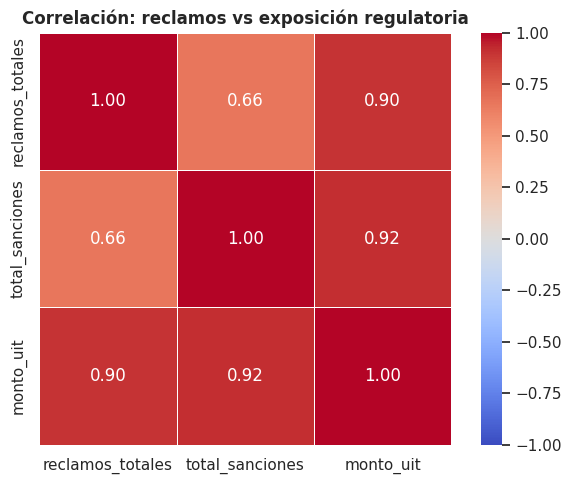

,reclamos_totales,total_sanciones,monto_uit
reclamos_totales,1.000,0.663,0.902
total_sanciones,0.663,1.000,0.918
monto_uit,0.902,0.918,1.000


In [50]:
# ============================================================
# Correlación DESPUÉS del enriquecimiento (nivel operadora)
# ============================================================
variables_corr = ['reclamos_totales', 'total_sanciones', 'monto_uit']
corr = df_empresa[variables_corr].corr()

plt.figure(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, linewidths=.5, square=True)
plt.title('Correlación: reclamos vs exposición regulatoria', fontweight='bold')
plt.tight_layout()
plt.show()

display(corr.round(3))

#Interpretación
El mapa de calor evidencia una alta correlación positiva entre los reclamos totales y la sanción económica en UIT ($r = 0.90$), superando a la cantidad física de sanciones ($r = 0.66$). Asimismo, el número de sanciones determina de forma casi directa el monto final ($r = 0.92$), demostrando que controlar el volumen inicial de reclamos es clave para mitigar la exposición financiera regulatoria.

# 11. Visualizaciones

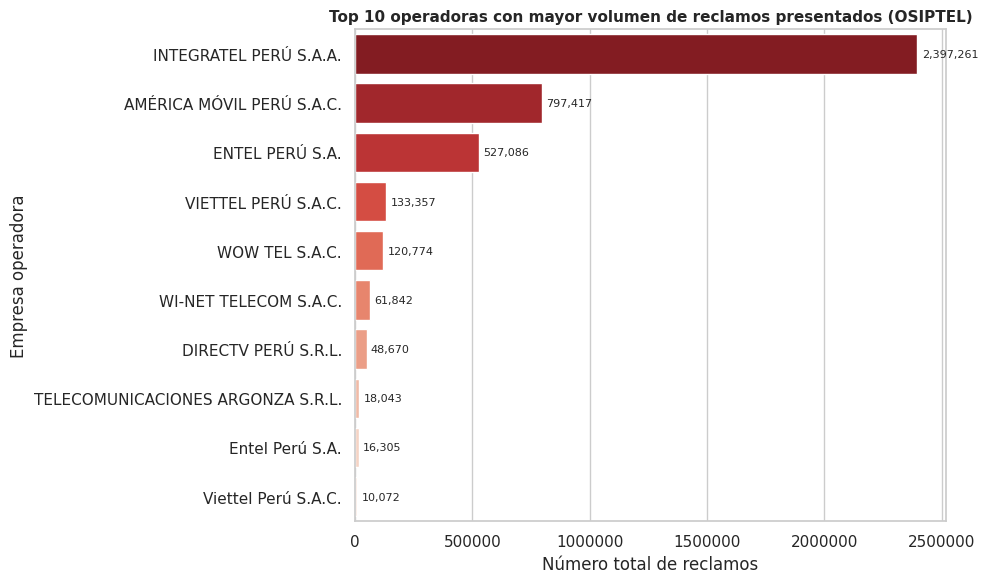

In [51]:
# ============================================================
# GRÁFICO 1: Top 10 empresas con más reclamos (OSIPTEL)
# ============================================================
top_10_empresas = (
    df_presentados.groupby('Empresa operadora')['N° de Reclamos Presentados']
    .sum().sort_values(ascending=False).head(10)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_10_empresas.values, y=top_10_empresas.index,
                 hue=top_10_empresas.index, palette='Reds_r', legend=False)
ax.ticklabel_format(style='plain', axis='x')
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=8)

plt.title('Top 10 operadoras con mayor volumen de reclamos presentados (OSIPTEL)',
          fontsize=11, fontweight='bold')
plt.xlabel('Número total de reclamos')
plt.ylabel('Empresa operadora')
plt.tight_layout()
plt.show()

#INTERPRETACION
El gráfico evidencia una alta concentración de reclamos, donde Integratel Perú lidera de forma abrumadora con cerca de 2.4 millones de casos, seguida a gran distancia por América Móvil y Entel. Asimismo, la presencia de nombres duplicados por diferencias de mayúsculas y minúsculas como Entel y Viettel que confirma la necesidad crítica de estandarizar las razones sociales en la fase de limpieza.

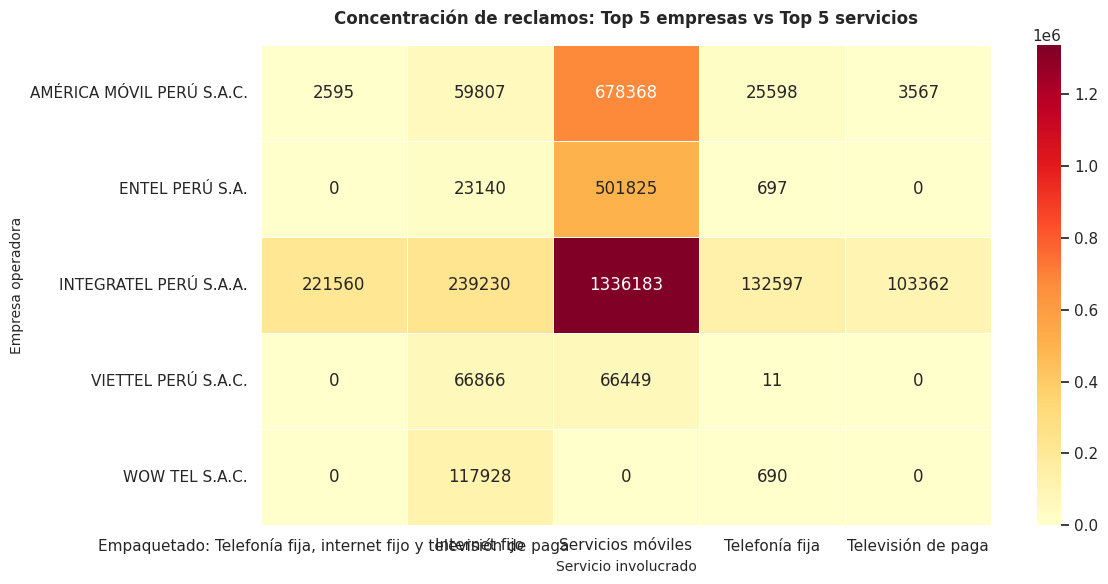

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtrar el Top 5 de empresas y servicios
top_empresas_lista = (
    df_presentados.groupby('Empresa operadora', observed=False)[
        'N° de Reclamos Presentados'
    ]
    .sum()
    .nlargest(5)
    .index
)

top_servicios_lista = (
    df_presentados.groupby('Servicio involucrado', observed=False)[
        'N° de Reclamos Presentados'
    ]
    .sum()
    .nlargest(5)
    .index
)

df_filtrado = df_presentados[
    df_presentados['Empresa operadora'].isin(top_empresas_lista)
    & df_presentados['Servicio involucrado'].isin(top_servicios_lista)
]

# 2. Crear la matriz pivotada convertida a enteros
matriz_reclamos = (
    df_filtrado.pivot_table(
        index='Empresa operadora',
        columns='Servicio involucrado',
        values='N° de Reclamos Presentados',
        aggfunc='sum',
        observed=False,
    )
    .fillna(0)
    .astype(int)
)

# 3. Configurar lienzo y generar el mapa de calor
plt.figure(figsize=(12, 6))
sns.heatmap(
    matriz_reclamos,
    annot=True,
    fmt='d',  # Formato número entero sin notación científica
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
)

# 4. Títulos y orientación plana de etiquetas
plt.title(
    'Concentración de reclamos: Top 5 empresas vs Top 5 servicios',
    fontweight='bold',
    fontsize=12,
    pad=15,
)
plt.xlabel('Servicio involucrado', fontsize=10)
plt.ylabel('Empresa operadora', fontsize=10)

plt.xticks(rotation=0)  # Mantiene las etiquetas del eje X horizontales
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#INTERPRETACION
El mapa de calor revela que los «Servicios móviles» concentran la gran mayoría de los reclamos del mercado, liderados masivamente por Integratel Perú que son 1.33 millones seguido de América Móvil y Entel. Por su parte, el Internet fijo emerge como el segundo foco crítico, representando la principal fuente de insatisfacción para operadoras como WOW Tel S.A.C.

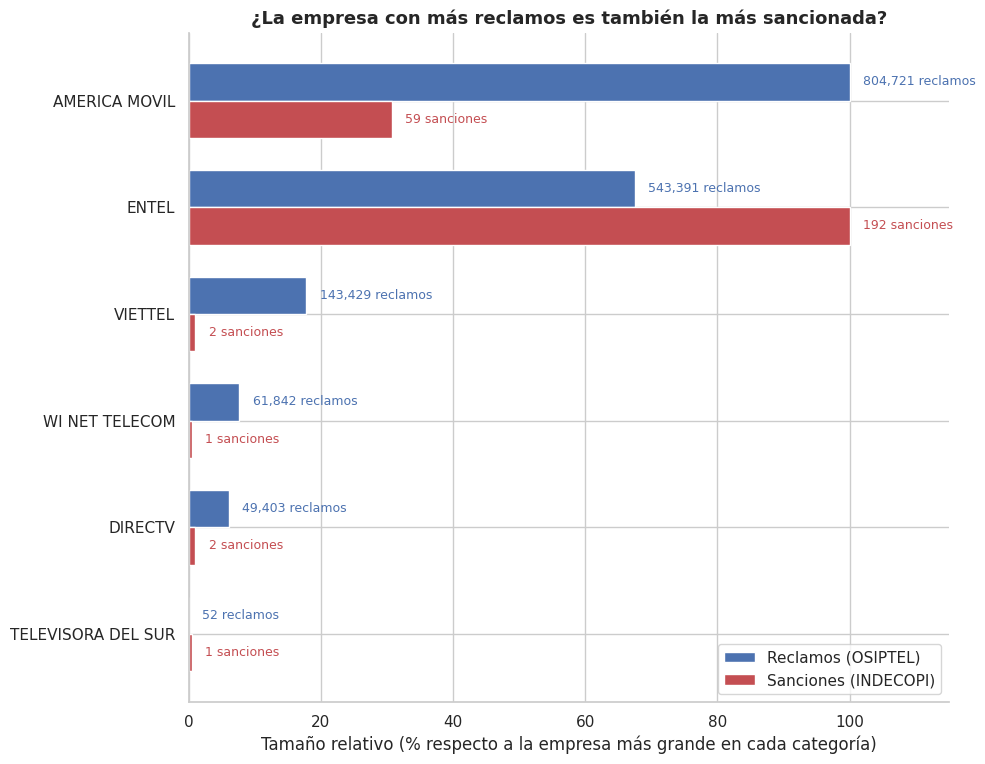

In [53]:
# ============================================================
# GRÁFICO 7 (v3): Barras dobles - Reclamos vs Sanciones por empresa
# ============================================================
df_plot = df_empresa.dropna(subset=['total_sanciones']).copy()

# Convertir a % del máximo de cada columna, para poder comparar "tamaños"
# aunque las unidades sean distintas (reclamos vs sanciones)
df_plot['pct_reclamos']  = df_plot['reclamos_totales'] / df_plot['reclamos_totales'].max() * 100
df_plot['pct_sanciones'] = df_plot['total_sanciones']  / df_plot['total_sanciones'].max()  * 100
df_plot = df_plot.sort_values('reclamos_totales', ascending=True)  # el #1 queda arriba

fig, ax = plt.subplots(figsize=(10, max(5, 1.3 * len(df_plot))))
y = np.arange(len(df_plot))
alto = 0.35

ax.barh(y + alto/2, df_plot['pct_reclamos'],  height=alto, color='#4C72B0', label='Reclamos (OSIPTEL)')
ax.barh(y - alto/2, df_plot['pct_sanciones'], height=alto, color='#C44E52', label='Sanciones (INDECOPI)')

for i, fila in enumerate(df_plot.itertuples()):
    ax.text(fila.pct_reclamos + 2, i + alto/2, f'{fila.reclamos_totales:,.0f} reclamos',
            va='center', fontsize=9, color='#4C72B0')
    ax.text(fila.pct_sanciones + 2, i - alto/2, f'{fila.total_sanciones:,.0f} sanciones',
            va='center', fontsize=9, color='#C44E52')

ax.set_yticks(y)
ax.set_yticklabels(df_plot['empresa_norm'])
ax.set_xlim(0, 115)
ax.set_xlabel('Tamaño relativo (% respecto a la empresa más grande en cada categoría)')
ax.set_title('¿La empresa con más reclamos es también la más sancionada?',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right', frameon=True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

#INTERPRETACION
El gráfico demuestra que un mayor volumen de reclamos no equivale directamente a más sanciones: aunque América Móvil lidera en quejas acumuladas que son 804,721 usuarios de Entel triplica holgadamente su nivel de penalización al concentrar la mayor cantidad de sanciones de INDECOPI (192 vs. 59). Esto evidencia una clara discrepancia entre la insatisfacción masiva del usuario y la efectividad punitiva regulatoria.

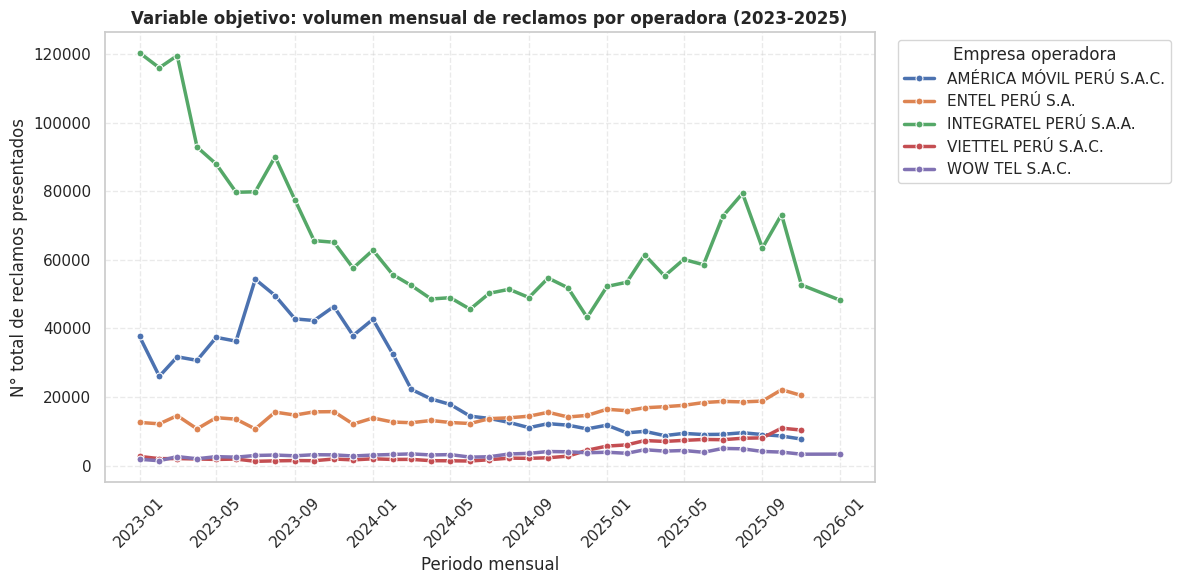

In [54]:
# ============================================================
# GRÁFICO 4: Variable objetivo - volumen mensual de reclamos (2023-2025)
# ============================================================
df_caso_e = df_presentados[
    (df_presentados['Mes'] >= '2023-01-01') &
    (df_presentados['Mes'] <= '2025-12-31')
].copy()

df_empresa_mes = (df_caso_e.groupby(['Empresa operadora', 'Mes'])
                  ['N° de Reclamos Presentados'].sum().reset_index())

top_5_empresas = (df_caso_e.groupby('Empresa operadora')
                  ['N° de Reclamos Presentados'].sum().nlargest(5).index)
df_top_empresa_mes = df_empresa_mes[
    df_empresa_mes['Empresa operadora'].isin(top_5_empresas)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_top_empresa_mes, x='Mes', y='N° de Reclamos Presentados',
             hue='Empresa operadora', marker='o', linewidth=2.5, markersize=5)

plt.title('Variable objetivo: volumen mensual de reclamos por operadora (2023-2025)',
          fontsize=12, fontweight='bold')
plt.xlabel('Periodo mensual')
plt.ylabel('N° total de reclamos presentados')
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.legend(title='Empresa operadora', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

#INTERPRETACION
El análisis temporal revela que Integratel lidera holgadamente el volumen mensual de reclamos durante todo el periodo 2023 hasta el 2025, alcanzando picos superiores a los 100,000 casos. Por su parte, América Móvil logró reducir drásticamente sus reclamos tras su pico a mediados de 2023, mientras que Entel muestra un crecimiento moderado pero constante, y operadoras como Viettel y WOW Tel permanecen estables en niveles mínimos.

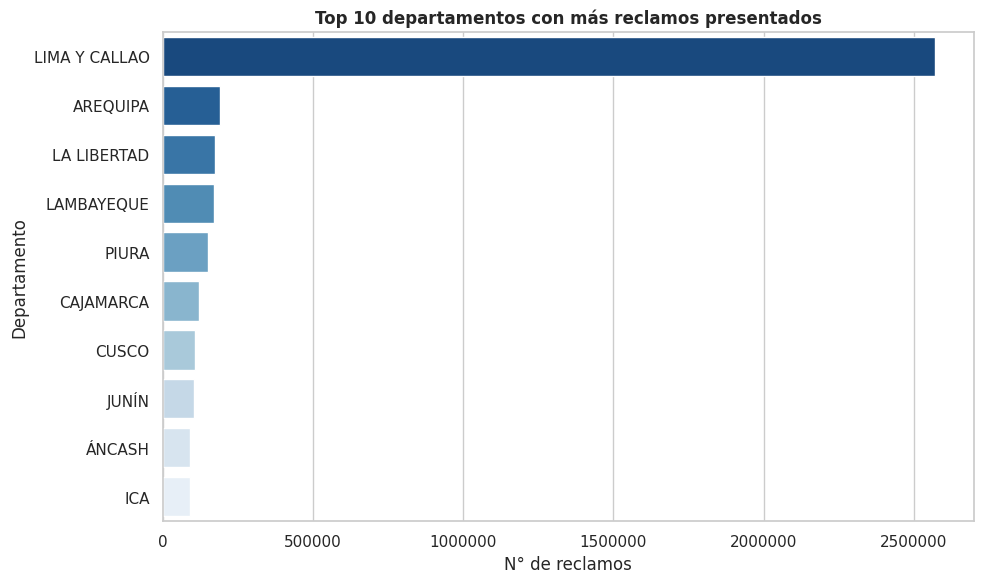

In [55]:
# ============================================================
# GRÁFICO 5: Top 10 departamentos con más reclamos
# ============================================================
reclamos_por_zona = (
    df_presentados.dropna(subset=['Departamento'])
    .groupby('Departamento')['N° de Reclamos Presentados']
    .sum().sort_values(ascending=False).head(10)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=reclamos_por_zona.values, y=reclamos_por_zona.index,
                 hue=reclamos_por_zona.index, palette='Blues_r', legend=False)
ax.ticklabel_format(style='plain', axis='x')
plt.title('Top 10 departamentos con más reclamos presentados', fontweight='bold')
plt.xlabel('N° de reclamos')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

#INTERPRETACION
El gráfico evidencia una extrema centralización geográfica, donde Lima y Callao concentran de manera abrumadora la mayoría de los reclamos del país, superando los 2.5 millones de casos. En contraste, departamentos como Arequipa, La Libertad y Lambayeque registran un volumen secundario que no supera los 200,000 reclamos cada uno, reflejando una brecha masiva frente a la capital.

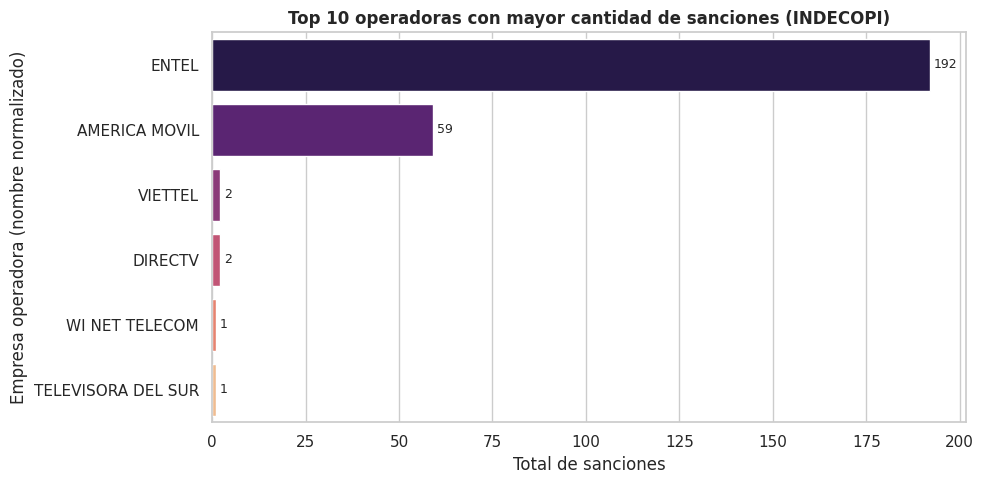

In [56]:
# ============================================================
# GRÁFICO 3: Top 10 operadoras con mayor cantidad de sanciones
# (requiere el dataset enriquecido)
# ============================================================
top10_sanciones = (
    df_empresa.dropna(subset=['total_sanciones'])
    .nlargest(10, 'total_sanciones')
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=top10_sanciones, x='total_sanciones', y='empresa_norm',
                 hue='empresa_norm', palette='magma', legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=9)

plt.title('Top 10 operadoras con mayor cantidad de sanciones (INDECOPI)',
          fontweight='bold')
plt.xlabel('Total de sanciones')
plt.ylabel('Empresa operadora (nombre normalizado)')
plt.tight_layout()
plt.show()

#INTERPRETACION
El gráfico muestra una extrema concentración en las sanciones impuestas por INDECOPI, donde Entel encabeza el ranking con 192 procesos, triplicando holgadamente a América Móvil que son 59 sanciones. En contraste, el resto de las operadoras registra una presencia casi testimonial con solo una o dos sanciones, evidenciando que la fiscalización punitiva recae casi en su totalidad sobre dos competidores.

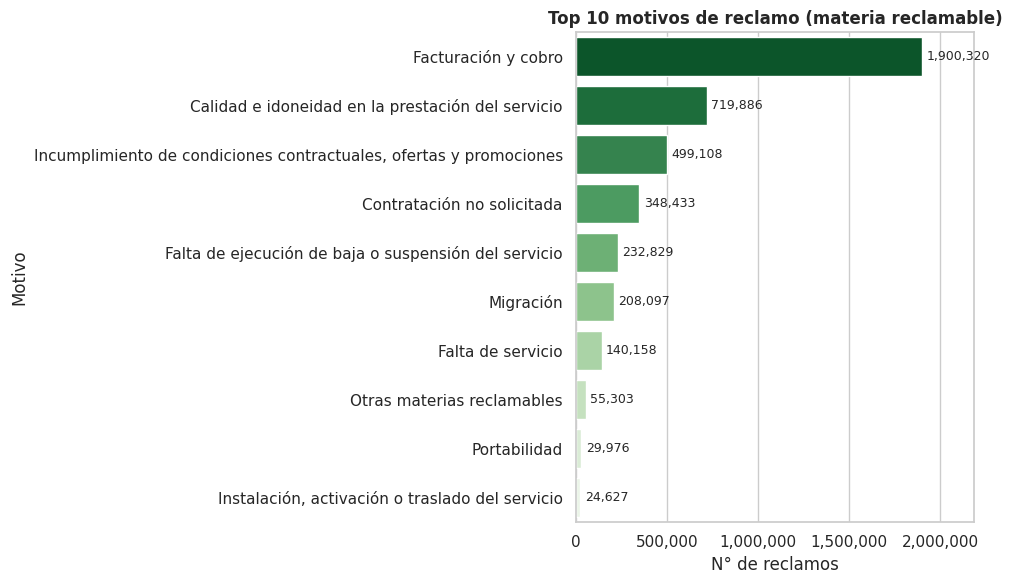

In [57]:
# ============================================================
# GRÁFICO 6: Top 10 motivos de reclamo (materia reclamable)
# ============================================================
import matplotlib.ticker as mticker

reclamos_por_motivo = (
    df_presentados.dropna(subset=['Materia reclamable'])
    .groupby('Materia reclamable')['N° de Reclamos Presentados']
    .sum().sort_values(ascending=False).head(10)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=reclamos_por_motivo.values, y=reclamos_por_motivo.index,
                 hue=reclamos_por_motivo.index, palette='Greens_r', legend=False)

# Formatear el eje X con comas de miles y menos marcas para que no se amontonen
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5))

# Además, poner el valor al final de cada barra (más claro que leer el eje)
for c in ax.containers:
    ax.bar_label(c, fmt='{:,.0f}', padding=3, fontsize=9)

plt.title('Top 10 motivos de reclamo (materia reclamable)', fontweight='bold')
plt.xlabel('N° de reclamos')
plt.ylabel('Motivo')
plt.xlim(0, reclamos_por_motivo.max() * 1.15)  # deja espacio para las etiquetas
plt.tight_layout()
plt.show()

# INTERPRETACION
El motivo de facturación y cobro domina de forma masiva los reclamos del sector con casi 1.9 millones de casos, superando por más del doble a la calidad e idoneidad del servicio abarcando 719 mil reclamos. Esto evidencia que el descontento de los usuarios proviene principalmente de disputas comerciales y de cobro, más que de fallas puramente técnicas.

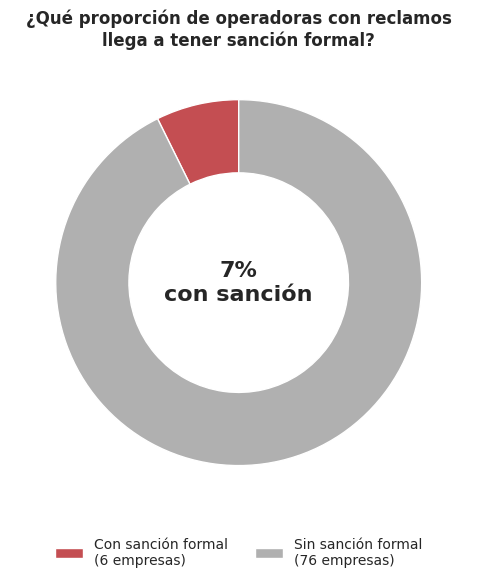

In [58]:
# ============================================================
# GRÁFICO 8: % de operadoras con reclamos que llegan a sanción formal (Responde a KPI's)
# ============================================================
n_con_sancion = int(df_empresa['total_sanciones'].notna().sum())
n_sin_sancion = int(df_empresa['total_sanciones'].isna().sum())
total = n_con_sancion + n_sin_sancion

fig, ax = plt.subplots(figsize=(6, 6))
valores   = [n_con_sancion, n_sin_sancion]
etiquetas = [f'Con sanción formal\n({n_con_sancion} empresas)',
             f'Sin sanción formal\n({n_sin_sancion} empresas)']
colores   = ['#C44E52', '#B0B0B0']

wedges, _ = ax.pie(valores, colors=colores, startangle=90,
                   wedgeprops=dict(width=0.4, edgecolor='white'))

pct = n_con_sancion / total * 100
ax.text(0, 0, f'{pct:.0f}%\ncon sanción', ha='center', va='center',
        fontsize=16, fontweight='bold')

ax.legend(wedges, etiquetas, loc='lower center', bbox_to_anchor=(0.5, -0.15),
          ncol=2, frameon=False, fontsize=10)
ax.set_title('¿Qué proporción de operadoras con reclamos\nllega a tener sanción formal?',
             fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()



#INTERPRETACION
El gráfico de dona evidencia que solo el 7% de las operadoras registradas en total van de 6 a 82 empresas en llegar a recibir una sanción formal. Esto demuestra que la abrumadora mayoría del mercado (93%) opera con reclamos pero sin penalizaciones oficiales, concentrando el actuar punitivo del regulador en un grupo sumamente reducido de competidores.

# Hallazgos del EDA


1. **Concentración fuerte del problema.** Top 5 de operadoras acumula la mayor parte de los reclamos del periodo (ver KPI 2). El mercado de reclamos replica la estructura oligopólica del mercado de telecomunicaciones.

2. **La tasa de coincidencia del cruce es inferior al 70%.** La tasa de coincidencia del cruce es inferior al 70%. Esto no es un defecto del método sino un hallazgo: OSIPTEL registra reclamos de decenas de operadoras locales y regionales, mientras que INDECOPI solo registra a los proveedores formalmente sancionados, que son casi exclusivamente las grandes operadoras.

3. **La mayoría de los reclamos no escala a sanción formal (KPI 3)**. El volumen de reclamos, por sí solo, es un predictor incompleto del riesgo regulatorio: hay operadoras con muchos reclamos y ninguna sanción, y viceversa.

4. **Presencia de outliers relevantes en las sanciones (ver EDA 3)**. Unas pocas empresas concentran montos en UIT muy por encima del rango intercuartílico; son casos que no deben eliminarse porque son precisamente el objeto de estudio.

5. **Concentración geográfica en Lima**, coherente con la densidad de usuarios, aunque conviene normalizar por número de líneas para no confundir volumen con incidencia.

6. **Estacionalidad visible en la serie mensual**, con picos que deberán modelarse en la Fase 2.

**Justificación:**

La tasa de coincidencia resulta ser menor de 70% debido a la asimetría de los datasets, en el database de OSIPTEL contiene más de 200,000 reclamos distribuidos entre decenas de operadoras locales y regionales. Pero la base de indecopi registra solo a los proveedores que han sido formalmente sancionados, los cuales considera a las grandes operadoras de telecomunicaciones.

Esta tasa nos brinda un insight de negocio fundamental, la mayoría de reclamos presentados en osiptel no escalan sanciones formales en indecopi, se concentran en el riesgo total y en las principales empresas de telecomunicaciones del mercado como Entel, Telefónica, America Móvil, etc.